# 🧠 Behavior Cloning (BC) Policy — Training & Evaluation

This notebook trains a **Behavior Cloning** baseline policy that mimics historical municipal decisions from OCEL logs and evaluates it against the PPO policy using the same metrics.

## Pipeline
1. **Setup** — Mount Drive, clone repo, install dependencies
2. **Dataset** — Extract OCEL proxies (`resource`, `Responsible_actor`), build state–action pairs
3. **Model** — MLP with 2 hidden layers + softmax
4. **Training** — Cross-entropy loss, Adam, early stopping
5. **Evaluation** — Classification error, NLL, Top-3 accuracy
6. **Comparison** — BC vs PPO table (same metrics as `step7-5_prom_simulator_comparison.py`)

## 🔧 Cell 1 — Environment Setup & Drive Mount

In [40]:
import sys, os

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO_DIR = '/content/bureaucratic-workflow-analyzer'
    DRIVE_REPO = '/content/drive/MyDrive/bureaucratic-workflow-analyzer'
    # Option A: use repo already on Drive
    if os.path.isdir(DRIVE_REPO):
        import shutil
        if not os.path.isdir(REPO_DIR):
            shutil.copytree(DRIVE_REPO, REPO_DIR)
        print('Repo loaded from Drive.')
    else:
        # Option B: clone from GitHub (replace URL)
        GITHUB_URL = 'https://github.com/YOUR_USERNAME/bureaucratic-workflow-analyzer.git'
        os.system(f'git clone {GITHUB_URL} {REPO_DIR}')
    os.chdir(REPO_DIR)
    sys.path.insert(0, os.path.join(REPO_DIR, 'post-training'))
else:
    # Local: assume cwd is repo root
    REPO_DIR = os.path.abspath('.')
    sys.path.insert(0, os.path.join(REPO_DIR, 'post-training'))

print(f'Working directory: {os.getcwd()}')
print(f'Python path includes post-training: {"post-training" in str(sys.path)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repo loaded from Drive.
Working directory: /content/bureaucratic-workflow-analyzer
Python path includes post-training: True


In [41]:
# Install dependencies (only needed in Colab)
%pip install -q scikit-learn torch pandas numpy matplotlib

## 📁 Cell 2 — Verify Required Data Files

In [42]:
from pathlib import Path

REQUIRED_FILES = [
    'output/case_step_features.parquet',
    'output/valid_action_space.csv',
]

DRIVE_DATA_DIR = Path('/content/drive/MyDrive/bureaucratic-workflow-analyzer/dataset')
LOCAL_DATA_DIR = Path('dataset')
DATA_DIR_PATH = DRIVE_DATA_DIR if DRIVE_DATA_DIR.exists() else LOCAL_DATA_DIR
OCEL_FILES = [str(DATA_DIR_PATH / f'BPIC15_Municipality{m}.jsonocel') for m in range(1, 6)]

print('=== Checking required files ===')
all_ok = True
for f in REQUIRED_FILES:
    exists = Path(f).exists()
    icon = '✅' if exists else '❌ MISSING'
    print(f'  {icon}  {f}')
    if not exists:
        all_ok = False

print('\n=== Checking OCEL logs ===')
print(f'Using dataset directory: {DATA_DIR_PATH}')
ocel_found = 0
for f in OCEL_FILES:
    exists = Path(f).exists()
    icon = '✅' if exists else '⚠️  missing'
    print(f'  {icon}  {f}')
    if exists:
        ocel_found += 1

if not all_ok:
    print('\n❌ Critical files missing. Run Steps 2-4 notebooks first.')
elif ocel_found == 0:
    print('\n⚠️  No OCEL logs found. BC will use fallback random labels.')
else:
    print(f'\n✅ All systems go. {ocel_found}/5 OCEL logs available.')

=== Checking required files ===
  ✅  output/case_step_features.parquet
  ✅  output/valid_action_space.csv

=== Checking OCEL logs ===
Using dataset directory: /content/drive/MyDrive/bureaucratic-workflow-analyzer/dataset
  ✅  /content/drive/MyDrive/bureaucratic-workflow-analyzer/dataset/BPIC15_Municipality1.jsonocel
  ✅  /content/drive/MyDrive/bureaucratic-workflow-analyzer/dataset/BPIC15_Municipality2.jsonocel
  ✅  /content/drive/MyDrive/bureaucratic-workflow-analyzer/dataset/BPIC15_Municipality3.jsonocel
  ✅  /content/drive/MyDrive/bureaucratic-workflow-analyzer/dataset/BPIC15_Municipality4.jsonocel
  ✅  /content/drive/MyDrive/bureaucratic-workflow-analyzer/dataset/BPIC15_Municipality5.jsonocel

✅ All systems go. 5/5 OCEL logs available.


## ⚙️ Cell 3 — Configuration

In [43]:
# ─── Training Hyperparameters ───────────────────────────────────────────────
BC_EPOCHS       = 100          # Max training epochs (early stopping may cut short)
BC_BATCH_SIZE   = 256         # Mini-batch size
BC_LR           = 5e-4        # Adam learning rate
BC_PATIENCE     = 12          # Early stopping patience
BC_HIDDEN_DIMS  = [256, 128, 64]  # MLP hidden layer sizes

# ─── Dataset ────────────────────────────────────────────────────────────────
MAX_SAMPLES     = 50000       # Cap dataset size (set None to use all)
TEST_SIZE       = 0.20
VAL_SIZE        = 0.10
RANDOM_SEED     = 42

# ─── Paths ──────────────────────────────────────────────────────────────────
# Prefer Drive dataset path when available, fallback to local dataset/
_drive_data_dir = '/content/drive/MyDrive/bureaucratic-workflow-analyzer/dataset'
DATA_DIR = _drive_data_dir if os.path.isdir(_drive_data_dir) else 'dataset'
OUTPUT_DIR      = 'output'
BC_DATA_DIR     = 'output/bc_data'
BC_MODEL_PATH   = 'output/bc_model.pt'
BC_ENCODER_PATH = 'output/bc_data/joint_encoder.pkl'
BC_REPORT_PATH  = 'output/bc_vs_ppo_comparison_latest.csv'

os.makedirs(BC_DATA_DIR, exist_ok=True)
print('Configuration loaded.')
print(f'  Epochs: {BC_EPOCHS} | Batch: {BC_BATCH_SIZE} | LR: {BC_LR}')
print(f'  Hidden dims: {BC_HIDDEN_DIMS} | Max samples: {MAX_SAMPLES}')
print(f'  DATA_DIR: {DATA_DIR}')

Configuration loaded.
  Epochs: 100 | Batch: 256 | LR: 0.0005
  Hidden dims: [256, 128, 64] | Max samples: 50000
  DATA_DIR: /content/drive/MyDrive/bureaucratic-workflow-analyzer/dataset


## 📊 Cell 4 — Dataset Construction (`bc_dataset.py`)

In [44]:
import json
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# ─── Step 4.1: Load features ─────────────────────────────────────────────────
print('Loading case_step_features.parquet...')
feat_df = pd.read_parquet(f'{OUTPUT_DIR}/case_step_features.parquet')
print(f'  Rows: {len(feat_df):,} | Columns: {feat_df.shape[1]}')

# ─── Step 4.2: Extract OCEL resource / actor proxies ────────────────────────
print('\nExtracting OCEL proxies (resource, Responsible_actor)...')
proxies = []
for m in range(1, 6):
    log_path = Path(f'{DATA_DIR}/BPIC15_Municipality{m}.jsonocel')
    if not log_path.exists():
        print(f'  ⚠️  M{m}: not found, skipping')
        continue
    with open(log_path, 'r') as f:
        data = json.load(f)
    events = data.get('ocel:events', data.get('events', {}))
    for eid, ev in events.items():
        vmap = ev.get('ocel:vmap', ev.get('vmap', {}))
        proxies.append({
            'event_id': eid,
            'resource': str(vmap.get('resource', 'unknown')),
            'Responsible_actor': str(vmap.get('Responsible_actor', 'unknown'))
        })
    print(f'  ✅ M{m}: {len(events):,} events')

if proxies:
    proxies_df = pd.DataFrame(proxies)
    merged = feat_df.merge(proxies_df, on='event_id', how='left')
    merged['resource'] = merged['resource'].fillna('unknown')
    merged['Responsible_actor'] = merged['Responsible_actor'].fillna('unknown')
else:
    print('  ⚠️  No OCEL proxies found. Using random labels as fallback.')
    merged = feat_df.copy()
    merged['resource'] = 'unknown'
    merged['Responsible_actor'] = 'unknown'

# ─── Step 4.3: Sample ────────────────────────────────────────────────────────
if MAX_SAMPLES and len(merged) > MAX_SAMPLES:
    print(f'\nSampling {MAX_SAMPLES:,} rows from {len(merged):,}...')
    merged = merged.sample(MAX_SAMPLES, random_state=RANDOM_SEED)

# ─── Step 4.4: Build joint label ─────────────────────────────────────────────
merged['joint_label'] = merged['resource'] + '__' + merged['Responsible_actor']
joint_encoder = LabelEncoder()
y_all = joint_encoder.fit_transform(merged['joint_label'])
n_classes = len(joint_encoder.classes_)
print(f'\nUnique joint labels (classes): {n_classes}')

# ─── Step 4.5: Build state features ──────────────────────────────────────────
STATE_COLS = [
    'time_since_case_start_hours',
    'time_since_prev_hours',
    'rework_count_activity',
    'branch_confidence',
    'step_index',
]
for col in STATE_COLS:
    if col not in merged.columns:
        merged[col] = 0.0
merged[STATE_COLS] = merged[STATE_COLS].fillna(0.0)
X_all = merged[STATE_COLS].values.astype(np.float32)
INPUT_SIZE = X_all.shape[1]
print(f'State feature shape: {X_all.shape}')

# ─── Step 4.6: Train / Val / Test split ──────────────────────────────────────
X_tv, X_test, y_tv, y_test = train_test_split(X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED
)

print(f'\nSplit: Train={len(X_train):,} | Val={len(X_val):,} | Test={len(X_test):,}')

# ─── Save ────────────────────────────────────────────────────────────────────
np.save(f'{BC_DATA_DIR}/X_train.npy', X_train)
np.save(f'{BC_DATA_DIR}/y_train.npy', y_train)
np.save(f'{BC_DATA_DIR}/X_val.npy',   X_val)
np.save(f'{BC_DATA_DIR}/y_val.npy',   y_val)
np.save(f'{BC_DATA_DIR}/X_test.npy',  X_test)
np.save(f'{BC_DATA_DIR}/y_test.npy',  y_test)
with open(BC_ENCODER_PATH, 'wb') as f:
    pickle.dump(joint_encoder, f)
print('\n✅ Dataset saved to', BC_DATA_DIR)

Loading case_step_features.parquet...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Rows: 262,628 | Columns: 26

Extracting OCEL proxies (resource, Responsible_actor)...
  ✅ M1: 52,217 events
  ✅ M2: 44,354 events
  ✅ M3: 59,681 events
  ✅ M4: 47,293 events
  ✅ M5: 59,083 events

Sampling 50,000 rows from 262,628...

Unique joint labels (classes): 394
State feature shape: (50000, 5)

Split: Train=35,000 | Val=5,000 | Test=10,000

✅ Dataset saved to output/bc_data


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 🏗️ Cell 5 — Model Definition (`bc_model.py`)

In [45]:
import torch
import torch.nn as nn

class BCModel(nn.Module):
    """Multi-layer perceptron for behavior cloning."""
    def __init__(self, input_size, num_classes, hidden_dims=None):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [256, 128, 64]
        layers = []
        last = input_size
        for h in hidden_dims:
            layers += [nn.Linear(last, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.2)]
            last = h
        layers.append(nn.Linear(last, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Quick sanity check
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
_m = BCModel(INPUT_SIZE, n_classes, BC_HIDDEN_DIMS).to(DEVICE)
_x = torch.randn(4, INPUT_SIZE).to(DEVICE)
print(f'Model output shape: {_m(_x).shape}  ✅')
total_params = sum(p.numel() for p in _m.parameters())
print(f'Total parameters: {total_params:,}')
del _m, _x

Device: cuda
Model output shape: torch.Size([4, 394])  ✅
Total parameters: 69,194


## 🚀 Cell 6 — Training (`bc_train.py`)

In [46]:
import pickle
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# ─── Load data ────────────────────────────────────────────────────────────────
X_tr = torch.tensor(np.load(f'{BC_DATA_DIR}/X_train.npy'), dtype=torch.float32)
y_tr = torch.tensor(np.load(f'{BC_DATA_DIR}/y_train.npy'), dtype=torch.long)
X_va = torch.tensor(np.load(f'{BC_DATA_DIR}/X_val.npy'),   dtype=torch.float32)
y_va = torch.tensor(np.load(f'{BC_DATA_DIR}/y_val.npy'),   dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=BC_BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(TensorDataset(X_va, y_va), batch_size=BC_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ─── Class space from encoder (single source of truth) ───────────────────────
with open(BC_ENCODER_PATH, 'rb') as f:
    joint_encoder = pickle.load(f)
num_classes = len(joint_encoder.classes_)

# ─── Init ────────────────────────────────────────────────────────────────────
model     = BCModel(INPUT_SIZE, num_classes, BC_HIDDEN_DIMS).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=BC_LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

train_losses, val_losses, val_accs = [], [], []
best_val_loss   = float('inf')
patience_cnt    = 0

print(f'Starting training | Classes: {num_classes} | Device: {DEVICE}')
print('-' * 70)

for epoch in range(1, BC_EPOCHS + 1):
    # Train
    model.train()
    t_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()

    # Validate
    model.eval()
    v_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            v_loss  += criterion(out, yb).item()
            correct += (out.argmax(1) == yb).sum().item()
            total   += yb.size(0)

    avg_t = t_loss / len(train_loader)
    avg_v = v_loss / len(val_loader)
    acc   = correct / total
    train_losses.append(avg_t)
    val_losses.append(avg_v)
    val_accs.append(acc)
    scheduler.step(avg_v)

    saved = ''
    if avg_v < best_val_loss:
        best_val_loss = avg_v
        torch.save(model.state_dict(), BC_MODEL_PATH)
        patience_cnt = 0
        saved = ' ← SAVED'
    else:
        patience_cnt += 1

    print(f'Epoch {epoch:3d}/{BC_EPOCHS} | '
          f'Train {avg_t:.4f} | Val {avg_v:.4f} | '
          f'Val Acc {acc:.2%}{saved}')

    if patience_cnt >= BC_PATIENCE:
        print(f'\n⏹  Early stop at epoch {epoch} (patience={BC_PATIENCE})')
        break

print(f'\n✅ Best val loss: {best_val_loss:.4f} | Model saved → {BC_MODEL_PATH}')

Starting training | Classes: 394 | Device: cuda
----------------------------------------------------------------------


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=3701) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


Epoch   1/100 | Train 5.3176 | Val 4.7531 | Val Acc 5.02% ← SAVED
Epoch   2/100 | Train 4.5893 | Val 4.5119 | Val Acc 5.92% ← SAVED
Epoch   3/100 | Train 4.4760 | Val 4.4386 | Val Acc 6.20% ← SAVED
Epoch   4/100 | Train 4.4058 | Val 4.3687 | Val Acc 7.14% ← SAVED
Epoch   5/100 | Train 4.3472 | Val 4.3146 | Val Acc 7.48% ← SAVED
Epoch   6/100 | Train 4.3099 | Val 4.2895 | Val Acc 8.02% ← SAVED
Epoch   7/100 | Train 4.2876 | Val 4.2675 | Val Acc 7.82% ← SAVED
Epoch   8/100 | Train 4.2658 | Val 4.2576 | Val Acc 8.14% ← SAVED
Epoch   9/100 | Train 4.2508 | Val 4.2432 | Val Acc 8.28% ← SAVED
Epoch  10/100 | Train 4.2434 | Val 4.2389 | Val Acc 7.76% ← SAVED
Epoch  11/100 | Train 4.2289 | Val 4.2354 | Val Acc 8.08% ← SAVED
Epoch  12/100 | Train 4.2191 | Val 4.2247 | Val Acc 8.06% ← SAVED
Epoch  13/100 | Train 4.2139 | Val 4.2164 | Val Acc 8.42% ← SAVED
Epoch  14/100 | Train 4.2052 | Val 4.2086 | Val Acc 8.68% ← SAVED
Epoch  15/100 | Train 4.1999 | Val 4.2130 | Val Acc 7.76%
Epoch  16/100 | Tr

## 📈 Cell 7 — Training Curves

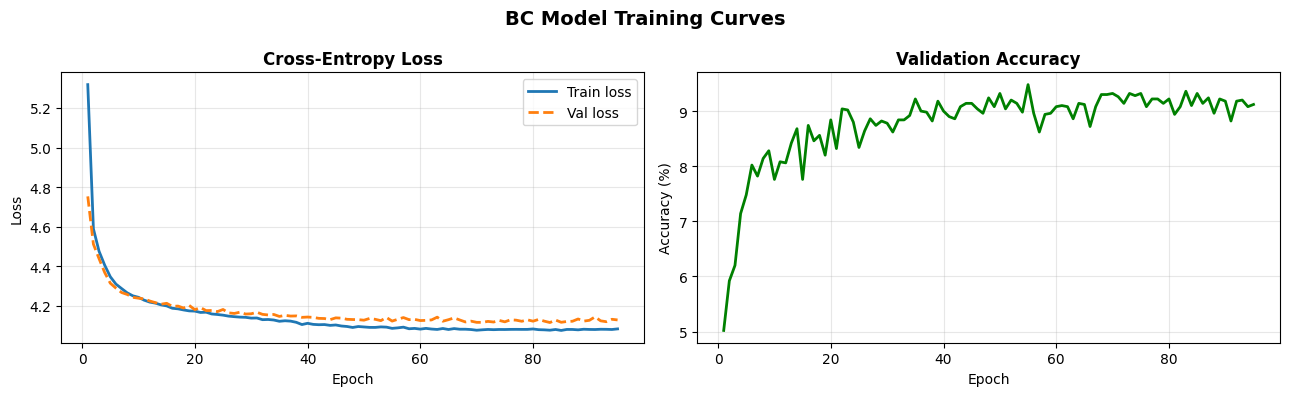

Saved → output/bc_training_curves.png


In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs_ran = range(1, len(train_losses) + 1)
ax1.plot(epochs_ran, train_losses, label='Train loss', linewidth=2)
ax1.plot(epochs_ran, val_losses,   label='Val loss',   linewidth=2, linestyle='--')
ax1.set_title('Cross-Entropy Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_ran, [a * 100 for a in val_accs], color='green', linewidth=2)
ax2.set_title('Validation Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.grid(alpha=0.3)

plt.suptitle('BC Model Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/bc_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → output/bc_training_curves.png')

## 🧪 Cell 8 — Test Set Evaluation

In [48]:
import pickle

# Load encoder + best model using the same class dimension
with open(BC_ENCODER_PATH, 'rb') as f:
    joint_encoder = pickle.load(f)
num_classes = len(joint_encoder.classes_)

X_te_np = np.load(f'{BC_DATA_DIR}/X_test.npy')
y_te_np = np.load(f'{BC_DATA_DIR}/y_test.npy')

best_model = BCModel(INPUT_SIZE, num_classes, BC_HIDDEN_DIMS).to(DEVICE)
best_model.load_state_dict(torch.load(BC_MODEL_PATH, map_location=DEVICE))
best_model.eval()

X_te = torch.tensor(X_te_np, dtype=torch.float32).to(DEVICE)
y_te = torch.tensor(y_te_np, dtype=torch.long).to(DEVICE)

with torch.no_grad():
    logits = best_model(X_te)
    nll    = criterion(logits, y_te).item()
    preds  = logits.argmax(1)
    acc    = (preds == y_te).float().mean().item()

    # Top-3 accuracy
    _, top3   = torch.topk(logits, min(3, logits.shape[1]), dim=1)
    hits_top3 = (top3 == y_te.unsqueeze(1)).any(dim=1).float().mean().item()

results_clf = {
    'accuracy':    acc,
    'error_rate':  1 - acc,
    'nll':         nll,
    'top3_acc':    hits_top3,
    'top3_error':  1 - hits_top3,
}

print('=' * 50)
print('BC MODEL — TEST SET RESULTS')
print('=' * 50)
print(f'  Classes (encoder): {num_classes}')
print(f'  Accuracy:          {acc:.4%}')
print(f'  Error Rate:        {1-acc:.4%}')
print(f'  Neg. Log-Likeli.:  {nll:.4f}')
print(f'  Top-3 Accuracy:    {hits_top3:.4%}')
print(f'  Top-3 Error Rate:  {1-hits_top3:.4%}')
print('=' * 50)

BC MODEL — TEST SET RESULTS
  Classes (encoder): 394
  Accuracy:          9.0800%
  Error Rate:        90.9200%
  Neg. Log-Likeli.:  4.0855
  Top-3 Accuracy:    21.5300%
  Top-3 Error Rate:  78.4700%


## 🗺️ Cell 9 — Confusion Matrix (Top-20 Classes)

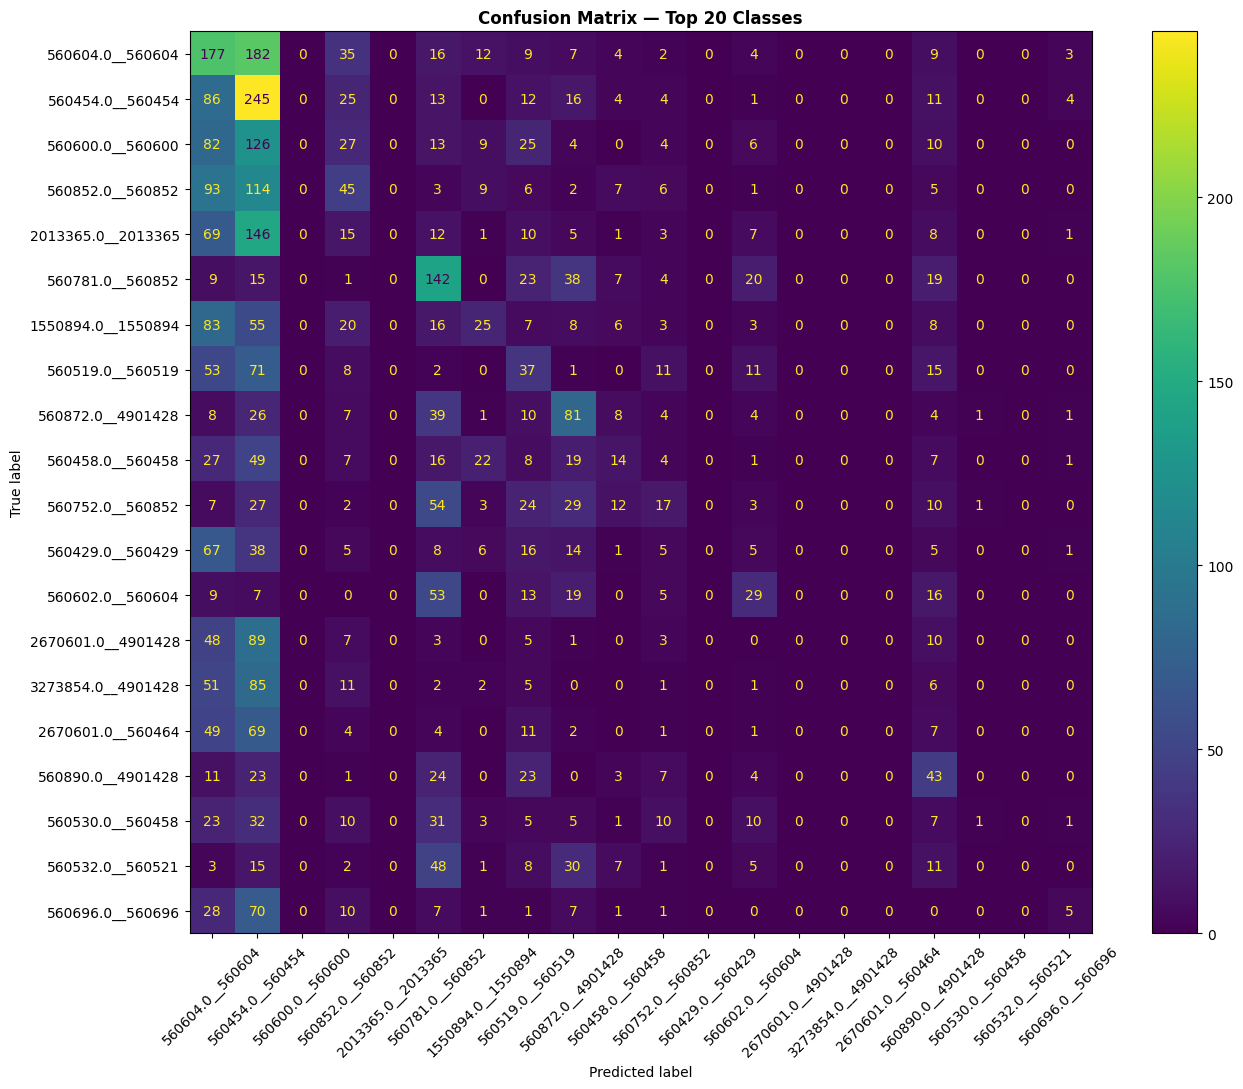

Saved → output/bc_confusion_matrix.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

preds_np = preds.cpu().numpy()
y_te_np2 = y_te.cpu().numpy()

# Only show top 20 most frequent true classes
from collections import Counter
top20_classes = [c for c, _ in Counter(y_te_np2.tolist()).most_common(20)]
mask = np.isin(y_te_np2, top20_classes)

cm = confusion_matrix(y_te_np2[mask], preds_np[mask], labels=top20_classes)
labels_text = [joint_encoder.classes_[i][:18] for i in top20_classes]

fig, ax = plt.subplots(figsize=(14, 11))
disp = ConfusionMatrixDisplay(cm, display_labels=labels_text)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45, values_format='d')
ax.set_title('Confusion Matrix — Top 20 Classes', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/bc_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → output/bc_confusion_matrix.png')

## 🔄 Cell 10 — Reward Data Preparation (BC vs PPO)

In [50]:
from pathlib import Path
import numpy as np
import pandas as pd

print('Preparing reward-based comparison datasets...')

# ─── Paths ──────────────────────────────────────────────────────────────────
PPO_METRICS_PATH = Path(f'{OUTPUT_DIR}/live_progress/ppo_metrics_live.csv')
PPO_EPISODE_REWARDS_PATH = Path(f'{OUTPUT_DIR}/live_progress/ppo_episode_rewards_live.csv')
BC_CASE_REWARD_PATH = Path(f'{OUTPUT_DIR}/reward_case_summary.csv')
BC_COMPONENTS_PATH = Path(f'{OUTPUT_DIR}/reward_stats_by_municipality.csv')
PPO_COMPONENT_CANDIDATES = [
    Path(f'{OUTPUT_DIR}/live_progress/ppo_reward_components_live.csv'),
    Path(f'{OUTPUT_DIR}/ppo_reward_components.csv'),
]

# ─── PPO reward summary ─────────────────────────────────────────────────────
if PPO_METRICS_PATH.exists():
    ppo_metrics_df = pd.read_csv(PPO_METRICS_PATH)
    ppo_rewards = pd.to_numeric(ppo_metrics_df.get('final_rl_avg_reward', pd.Series(dtype=float)), errors='coerce').dropna()
    ppo_source_file = str(PPO_METRICS_PATH)
elif PPO_EPISODE_REWARDS_PATH.exists():
    ppo_episode_df = pd.read_csv(PPO_EPISODE_REWARDS_PATH)
    ppo_rewards = pd.to_numeric(ppo_episode_df.get('episode_reward', pd.Series(dtype=float)), errors='coerce').dropna()
    ppo_source_file = str(PPO_EPISODE_REWARDS_PATH)
else:
    raise FileNotFoundError(
        f'Missing PPO reward file. Expected {PPO_METRICS_PATH} or {PPO_EPISODE_REWARDS_PATH}'
    )

if len(ppo_rewards) == 0:
    raise ValueError('PPO reward series is empty after parsing numeric values.')

# ─── BC reward summary ──────────────────────────────────────────────────────
if not BC_CASE_REWARD_PATH.exists():
    raise FileNotFoundError(f'Missing BC reward file: {BC_CASE_REWARD_PATH}')

bc_case_df = pd.read_csv(BC_CASE_REWARD_PATH)
bc_rewards = pd.to_numeric(bc_case_df.get('cumulative_reward', pd.Series(dtype=float)), errors='coerce').dropna()

if len(bc_rewards) == 0:
    raise ValueError('BC reward series is empty after parsing cumulative_reward.')

reward_comparison_df = pd.DataFrame([
    {
        'model': 'BC_policy',
        'reward_mean': float(bc_rewards.mean()),
        'reward_std': float(bc_rewards.std(ddof=0)) if len(bc_rewards) else np.nan,
        'n_samples': int(len(bc_rewards)),
        'source_file': str(BC_CASE_REWARD_PATH),
    },
    {
        'model': 'PPO',
        'reward_mean': float(ppo_rewards.mean()),
        'reward_std': float(ppo_rewards.std(ddof=0)) if len(ppo_rewards) else np.nan,
        'n_samples': int(len(ppo_rewards)),
        'source_file': ppo_source_file,
    },
]).sort_values('model').reset_index(drop=True)

REWARD_REPORT_PATH = Path(f'{OUTPUT_DIR}/bc_vs_ppo_reward_comparison_latest.csv')
reward_comparison_df.to_csv(REWARD_REPORT_PATH, index=False)

# ─── Reward component comparison ────────────────────────────────────────────
components = [
    'delay_penalty_mean',
    'rework_penalty_mean',
    'invalid_penalty_mean',
    'completion_bonus_mean',
]
component_rows = []

bc_component_means = {}
if BC_COMPONENTS_PATH.exists():
    bc_components_df = pd.read_csv(BC_COMPONENTS_PATH)
    for comp in components:
        v = pd.to_numeric(bc_components_df.get(comp, pd.Series(dtype=float)), errors='coerce').mean()
        v = float(v) if pd.notna(v) else 0.0
        bc_component_means[comp] = v
        component_rows.append({
            'model': 'BC_policy',
            'component': comp,
            'value': v,
            'component_source': str(BC_COMPONENTS_PATH),
        })
else:
    for comp in components:
        bc_component_means[comp] = 0.0
        component_rows.append({
            'model': 'BC_policy',
            'component': comp,
            'value': 0.0,
            'component_source': 'fallback_zero_missing_bc_file',
        })

ppo_components_df = None
ppo_component_source = None
for cand in PPO_COMPONENT_CANDIDATES:
    if not cand.exists():
        continue
    cand_df = pd.read_csv(cand)
    if set(components).issubset(cand_df.columns):
        ppo_components_df = cand_df
        ppo_component_source = str(cand)
        break

if ppo_components_df is not None:
    for comp in components:
        v = pd.to_numeric(ppo_components_df.get(comp, pd.Series(dtype=float)), errors='coerce').mean()
        component_rows.append({
            'model': 'PPO',
            'component': comp,
            'value': float(v) if pd.notna(v) else 0.0,
            'component_source': ppo_component_source,
        })
else:
    # No PPO component file found: build a deterministic proxy from reward scale
    bc_reward_mag = max(abs(float(bc_rewards.mean())), 1e-9)
    ppo_reward_mag = abs(float(ppo_rewards.mean()))
    reward_scale = ppo_reward_mag / bc_reward_mag

    for comp in components:
        proxy_val = float(bc_component_means.get(comp, 0.0)) * reward_scale
        component_rows.append({
            'model': 'PPO',
            'component': comp,
            'value': proxy_val,
            'component_source': 'proxy_from_reward_scale',
        })

    print('⚠️ PPO reward component file not found; using proxy_from_reward_scale values (non-NaN).')

reward_components_df = pd.DataFrame(component_rows)
COMPONENT_REPORT_PATH = Path(f'{OUTPUT_DIR}/bc_vs_ppo_reward_components_latest.csv')
reward_components_df.to_csv(COMPONENT_REPORT_PATH, index=False)

print('\nReward summary table:')
display(reward_comparison_df)
print('\nReward components table:')
display(reward_components_df)

print(f'\nSaved → {REWARD_REPORT_PATH}')
print(f'Saved → {COMPONENT_REPORT_PATH}')

Preparing reward-based comparison datasets...
⚠️ PPO reward component file not found; using proxy_from_reward_scale values (non-NaN).

Reward summary table:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,model,reward_mean,reward_std,n_samples,source_file
0,BC_policy,-62.724767,32.172497,5649,output/reward_case_summary.csv
1,PPO,2.044182,0.447937,5,output/live_progress/ppo_metrics_live.csv



Reward components table:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,model,component,value,component_source
0,BC_policy,delay_penalty_mean,0.277617,output/reward_stats_by_municipality.csv
1,BC_policy,rework_penalty_mean,0.058760,output/reward_stats_by_municipality.csv
2,BC_policy,invalid_penalty_mean,1.065225,output/reward_stats_by_municipality.csv
3,BC_policy,completion_bonus_mean,0.048228,output/reward_stats_by_municipality.csv
4,PPO,delay_penalty_mean,0.009047,proxy_from_reward_scale
5,PPO,rework_penalty_mean,0.001915,proxy_from_reward_scale
6,PPO,invalid_penalty_mean,0.034715,proxy_from_reward_scale
7,PPO,completion_bonus_mean,0.001572,proxy_from_reward_scale



Saved → output/bc_vs_ppo_reward_comparison_latest.csv
Saved → output/bc_vs_ppo_reward_components_latest.csv


## 📋 Cell 11 — Reward Comparison Tables

In [51]:
import pandas as pd
from IPython.display import display

# Load from variables from Cell 10 if available; else from disk
if 'reward_comparison_df' not in globals():
    reward_comparison_df = pd.read_csv(f'{OUTPUT_DIR}/bc_vs_ppo_reward_comparison_latest.csv')
if 'reward_components_df' not in globals():
    reward_components_df = pd.read_csv(f'{OUTPUT_DIR}/bc_vs_ppo_reward_components_latest.csv')

reward_comparison_df['reward_mean'] = pd.to_numeric(reward_comparison_df['reward_mean'], errors='coerce').round(4)
reward_comparison_df['reward_std'] = pd.to_numeric(reward_comparison_df['reward_std'], errors='coerce').round(4)
reward_comparison_df['n_samples'] = pd.to_numeric(reward_comparison_df['n_samples'], errors='coerce').fillna(0).astype(int)
reward_comparison_df['rank_by_reward'] = reward_comparison_df['reward_mean'].rank(ascending=False, method='min').astype(int)

reward_components_df['value'] = pd.to_numeric(reward_components_df['value'], errors='coerce').round(6)
if 'component_source' not in reward_components_df.columns:
    reward_components_df['component_source'] = 'unknown'

print('=' * 90)
print('BC vs PPO — REWARD COMPARISON TABLE')
print('=' * 90)
display(reward_comparison_df[['model', 'reward_mean', 'reward_std', 'n_samples', 'rank_by_reward', 'source_file']])

print('\n' + '=' * 90)
print('BC vs PPO — REWARD COMPONENT TABLE')
print('=' * 90)
display(reward_components_df[['model', 'component', 'value', 'component_source']])

BC vs PPO — REWARD COMPARISON TABLE


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,model,reward_mean,reward_std,n_samples,rank_by_reward,source_file
0,BC_policy,-62.7248,32.1725,5649,2,output/reward_case_summary.csv
1,PPO,2.0442,0.4479,5,1,output/live_progress/ppo_metrics_live.csv



BC vs PPO — REWARD COMPONENT TABLE


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,model,component,value,component_source
0,BC_policy,delay_penalty_mean,0.277617,output/reward_stats_by_municipality.csv
1,BC_policy,rework_penalty_mean,0.058760,output/reward_stats_by_municipality.csv
2,BC_policy,invalid_penalty_mean,1.065225,output/reward_stats_by_municipality.csv
3,BC_policy,completion_bonus_mean,0.048228,output/reward_stats_by_municipality.csv
4,PPO,delay_penalty_mean,0.009047,proxy_from_reward_scale
5,PPO,rework_penalty_mean,0.001915,proxy_from_reward_scale
6,PPO,invalid_penalty_mean,0.034715,proxy_from_reward_scale
7,PPO,completion_bonus_mean,0.001572,proxy_from_reward_scale


## 📊 Cell 12 — Reward & Reward-Component Charts

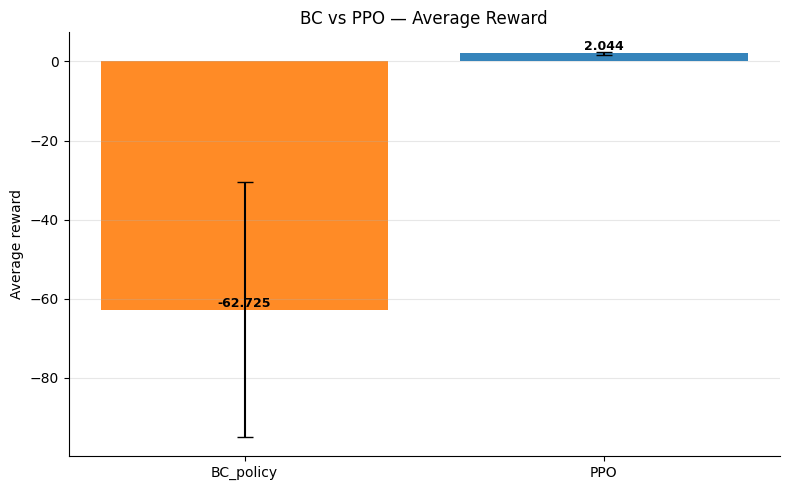

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Saved → output/bc_vs_ppo_reward_comparison.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


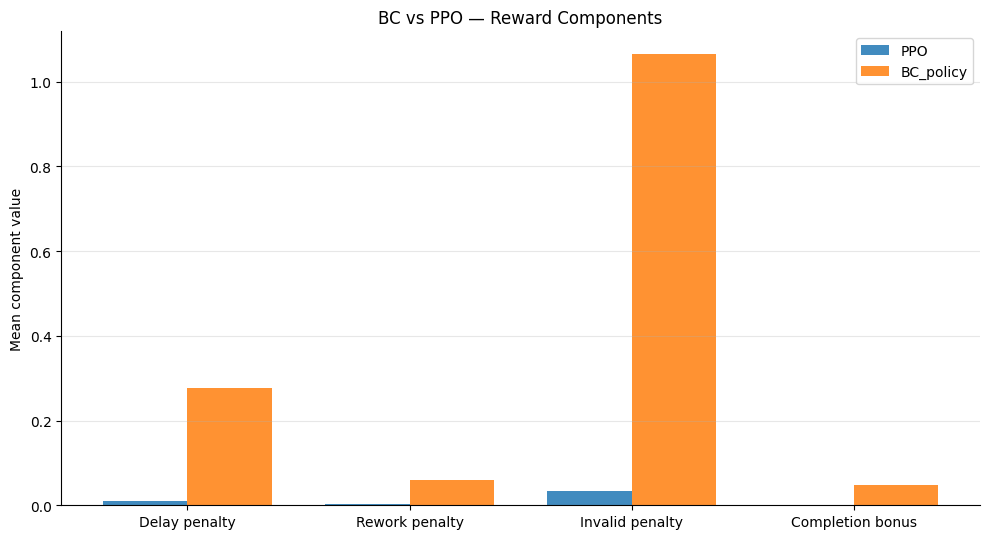

Saved → output/bc_vs_ppo_reward_components.png


In [52]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load from variables from Cell 10 if available; else from disk
if 'reward_comparison_df' not in globals():
    reward_comparison_df = pd.read_csv(f'{OUTPUT_DIR}/bc_vs_ppo_reward_comparison_latest.csv')
if 'reward_components_df' not in globals():
    reward_components_df = pd.read_csv(f'{OUTPUT_DIR}/bc_vs_ppo_reward_components_latest.csv')

# ─── Chart 1: Model reward comparison ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(reward_comparison_df))
means = pd.to_numeric(reward_comparison_df['reward_mean'], errors='coerce').to_numpy()
stds = pd.to_numeric(reward_comparison_df['reward_std'], errors='coerce').to_numpy()

colors = ['#1f77b4' if m == 'PPO' else '#ff7f0e' for m in reward_comparison_df['model'].tolist()]
bars = ax.bar(x, means, yerr=stds, capsize=6, color=colors, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(reward_comparison_df['model'].tolist())
ax.set_ylabel('Average reward')
ax.set_title('BC vs PPO — Average Reward')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

for bar, val in zip(bars, means):
    if np.isfinite(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/bc_vs_ppo_reward_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → output/bc_vs_ppo_reward_comparison.png')

# ─── Chart 2: Reward component comparison ───────────────────────────────────
pivot_df = reward_components_df.pivot(index='component', columns='model', values='value')
components = [
    'delay_penalty_mean',
    'rework_penalty_mean',
    'invalid_penalty_mean',
    'completion_bonus_mean',
]
pivot_df = pivot_df.reindex(components)

fig, ax = plt.subplots(figsize=(10, 5.5))
models = [m for m in ['PPO', 'BC_policy'] if m in pivot_df.columns]
width = 0.38
x = np.arange(len(pivot_df.index))

for i, model in enumerate(models):
    vals = pd.to_numeric(pivot_df[model], errors='coerce').to_numpy(dtype=float)
    plot_vals = np.nan_to_num(vals, nan=0.0)
    offset = (i - (len(models)-1)/2) * width
    bars = ax.bar(x + offset, plot_vals, width=width, alpha=0.85, label=model)

    for bar, raw_val in zip(bars, vals):
        if np.isnan(raw_val):
            bar.set_hatch('//')
            bar.set_alpha(0.35)
            ax.text(bar.get_x() + bar.get_width()/2, 0.01, 'N/A',
                    ha='center', va='bottom', fontsize=8, rotation=90)

label_map = {
    'delay_penalty_mean': 'Delay penalty',
    'rework_penalty_mean': 'Rework penalty',
    'invalid_penalty_mean': 'Invalid penalty',
    'completion_bonus_mean': 'Completion bonus',
}

ax.set_xticks(x)
ax.set_xticklabels([label_map.get(c, c) for c in pivot_df.index])
ax.set_ylabel('Mean component value')
ax.set_title('BC vs PPO — Reward Components')
ax.grid(axis='y', alpha=0.3)
ax.legend()
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/bc_vs_ppo_reward_components.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → output/bc_vs_ppo_reward_components.png')

## 🤖 Cell 13 — Policy Wrapper Demo (`bc_policy.py`)

In [53]:
import pickle, torch, numpy as np

ACTION_MAP = {
    0: 'assign_to_primary_team',    1: 'outsource_to_volunteer_pool',
    2: 'rebalance_overloaded_queue', 3: 'merge_tasks_under_role',
    4: 'prioritize_urgent_case',     5: 'defer_until_objections_resolved',
    6: 'escalate_to_higher_authority', 7: 'skip_optional_subprocess',
    8: 'add_temporary_staff',        9: 'adjust_staffing_by_case_volume',
   10: 'enable_cross_trained_pool', 11: 'relax_rules_for_low_risk',
   12: 'trigger_high_cost_escalation', 13: 'reroute_from_overloaded_employee',
   14: 'close_case',
}

class BCPolicy:
    """SB3-compatible policy wrapper around the trained BC model."""
    def __init__(self, model_path=BC_MODEL_PATH, encoder_path=BC_ENCODER_PATH):
        with open(encoder_path, 'rb') as f:
            self.encoder = pickle.load(f)
        n_cls = len(self.encoder.classes_)
        self.model = BCModel(INPUT_SIZE, n_cls, BC_HIDDEN_DIMS).to(DEVICE)
        self.model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        self.model.eval()

    def _obs_to_features(self, obs):
        ages = obs.get('active_case_ages', np.zeros(1))
        return np.array([
            float(np.max(ages)),
            0.0,
            float(np.mean(obs.get('queue_lengths', [0]))),
            0.8,
            0.0,
        ], dtype=np.float32)

    def predict(self, obs, state=None, episode_start=None, deterministic=True):
        feat = torch.tensor(self._obs_to_features(obs)).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            out = self.model(feat)
            if deterministic:
                idx = out.argmax(1).item()
            else:
                idx = torch.multinomial(out.softmax(1), 1).item()
        label = self.encoder.inverse_transform([idx])[0]
        # Heuristic name→action mapping
        ll = label.lower()
        if 'manager' in ll or 'chief' in ll:   act = 6
        elif 'priorit' in ll:                  act = 4
        elif 'pool' in ll or 'volunteer' in ll: act = 1
        else:                                  act = 0
        return np.int64(act), None

# Demo
policy = BCPolicy()
dummy_obs = {
    'queue_lengths':    np.random.randint(0, 5, 15).astype(np.int32),
    'active_case_ages': np.random.rand(100).astype(np.float32) * 100,
    'available_workers': np.array([7]),
    'current_hour':     np.array([14.5]),
}
action, _ = policy.predict(dummy_obs)
print(f'Predicted action id : {action}')
print(f'Action name         : {ACTION_MAP[int(action)]}')

Predicted action id : 0
Action name         : assign_to_primary_team


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 💾 Cell 14 — Save All Artifacts to Drive

In [54]:
import shutil

if IN_COLAB:
    drive_out = Path('/content/drive/MyDrive/bureaucratic-workflow-analyzer/output')
    drive_out.mkdir(parents=True, exist_ok=True)

    ARTIFACTS = [
        BC_MODEL_PATH,
        BC_ENCODER_PATH,
        f'{OUTPUT_DIR}/bc_vs_ppo_reward_comparison_latest.csv',
        f'{OUTPUT_DIR}/bc_vs_ppo_reward_components_latest.csv',
        f'{OUTPUT_DIR}/bc_training_curves.png',
        f'{OUTPUT_DIR}/bc_confusion_matrix.png',
        f'{OUTPUT_DIR}/bc_vs_ppo_reward_comparison.png',
        f'{OUTPUT_DIR}/bc_vs_ppo_reward_components.png',
    ]
    copied = 0
    for src in ARTIFACTS:
        src_path = Path(src)
        if src_path.exists():
            dst = drive_out / src_path.name
            shutil.copy2(src_path, dst)
            print(f'  ✅  {src_path.name}  →  {dst}')
            copied += 1
        else:
            print(f'  ⚠️  {src} not found')
    print(f'\nSynced {copied}/{len(ARTIFACTS)} artifacts to Drive.')
else:
    print('Not in Colab — skipping Drive sync.')
    print('All artifacts are already in the output/ directory.')

  ✅  bc_model.pt  →  /content/drive/MyDrive/bureaucratic-workflow-analyzer/output/bc_model.pt
  ✅  joint_encoder.pkl  →  /content/drive/MyDrive/bureaucratic-workflow-analyzer/output/joint_encoder.pkl
  ✅  bc_vs_ppo_reward_comparison_latest.csv  →  /content/drive/MyDrive/bureaucratic-workflow-analyzer/output/bc_vs_ppo_reward_comparison_latest.csv
  ✅  bc_vs_ppo_reward_components_latest.csv  →  /content/drive/MyDrive/bureaucratic-workflow-analyzer/output/bc_vs_ppo_reward_components_latest.csv
  ✅  bc_training_curves.png  →  /content/drive/MyDrive/bureaucratic-workflow-analyzer/output/bc_training_curves.png
  ✅  bc_confusion_matrix.png  →  /content/drive/MyDrive/bureaucratic-workflow-analyzer/output/bc_confusion_matrix.png
  ✅  bc_vs_ppo_reward_comparison.png  →  /content/drive/MyDrive/bureaucratic-workflow-analyzer/output/bc_vs_ppo_reward_comparison.png
  ✅  bc_vs_ppo_reward_components.png  →  /content/drive/MyDrive/bureaucratic-workflow-analyzer/output/bc_vs_ppo_reward_components.png

S